In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\Tanuja\Desktop\Jupyter Notebook\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
invoice = pd.read_csv(r"C:\Users\Tanuja\Desktop\Data Analytics Projects\Automated Invoice Generator\Dataset\invoices.csv")

In [3]:
invoice.shape

(10000, 11)

In [4]:
invoice.head()

,first_name,last_name,email,product_id,qty,amount,invoice_date,address,city,stock_code,job
0,Carmen Nixon,Todd Anderson,marvinjackson@example.com,133,9,14.57,10/9/1982,283 Wendy Common,West Alexander,36239634,Logistics and distribution manager
1,Mrs. Heather Miller,Julia Moore,jeffrey84@example.net,155,5,65.48,3/10/2012,13567 Patricia Circles Apt. 751,Andreamouth,2820163,Osteopath
2,Crystal May,Philip Moody,ugoodman@example.com,151,9,24.66,23/03/1976,6389 Debbie Island Suite 470,Coxbury,27006726,Economist
3,Bobby Weber,Mark Scott,ssanchez@example.com,143,4,21.34,17/08/1986,6362 Ashley Plaza Apt. 994,Ninaland,83036521,Sports administrator
4,Kristen Welch,David David,cynthia66@example.net,168,2,83.90,11/6/1996,463 Steven Cliffs Suite 757,Isaiahview,80142652,Chief Marketing Officer


In [5]:
invoice.tail()

,first_name,last_name,email,product_id,qty,amount,invoice_date,address,city,stock_code,job
9995,Daniel Chapman,Ralph Price,davidrice@example.com,133,1,39.82,14/05/2004,8220 Stewart Isle Apt. 382,New Willieberg,53513212,"Surveyor, insurance"
9996,Jonathan Cabrera,John Baldwin,jennifer66@example.com,133,1,21.94,7/10/1994,48045 Harris Mountain Apt. 857,Jameston,61754737,Writer
9997,David Thomas,Brandy Bishop,moraleskimberly@example.org,173,2,62.05,27/06/2010,872 Tonya Drive,West Eric,17037907,"Surveyor, quantity"
9998,Rose Bond,Daniel Lopez,vleon@example.net,146,5,11.35,16/01/2011,635 Saunders Creek Suite 967,Port Catherine,32764659,Architectural technologist
9999,Jeffrey Johnson,Yolanda Mcgrath,mchen@example.net,193,2,39.04,25/07/2021,783 Owens Way,Lake Ashleyborough,52015342,"Designer, textile"


In [6]:
invoice.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   first_name    10000 non-null  object 
 1   last_name     10000 non-null  object 
 2   email         10000 non-null  object 
 3   product_id    10000 non-null  int64  
 4   qty           10000 non-null  int64  
 5   amount        10000 non-null  float64
 6   invoice_date  10000 non-null  object 
 7   address       10000 non-null  object 
 8   city          10000 non-null  object 
 9   stock_code    10000 non-null  int64  
 10  job           10000 non-null  object 
dtypes: float64(1), int64(3), object(7)
memory usage: 859.5+ KB


In [7]:
invoice.describe()

,product_id,qty,amount,stock_code
count,10000.000000,10000.000000,10000.000000,1.000000e+04
mean,149.746700,5.005900,52.918236,4.950036e+07
std,28.728186,2.576767,27.434579,2.903081e+07
min,100.000000,1.000000,5.010000,1.977000e+03
25%,125.000000,3.000000,29.137500,2.425234e+07
50%,150.000000,5.000000,53.485000,4.931714e+07
75%,175.000000,7.000000,76.520000,7.457446e+07
max,199.000000,9.000000,99.990000,9.999216e+07


In [8]:
invoice.isnull().sum()

first_name      0
last_name       0
email           0
product_id      0
qty             0
amount          0
invoice_date    0
address         0
city            0
stock_code      0
job             0
dtype: int64

In [9]:
invoice.duplicated().sum()

0

In [10]:
(invoice.isnull().sum()/len(invoice))*100

first_name      0.0
last_name       0.0
email           0.0
product_id      0.0
qty             0.0
amount          0.0
invoice_date    0.0
address         0.0
city            0.0
stock_code      0.0
job             0.0
dtype: float64

In [11]:
invoice[invoice.duplicated()]

,first_name,last_name,email,product_id,qty,amount,invoice_date,address,city,stock_code,job


In [12]:
invoice.dtypes

first_name       object
last_name        object
email            object
product_id        int64
qty               int64
amount          float64
invoice_date     object
address          object
city             object
stock_code        int64
job              object
dtype: object

In [13]:
invoice["city"].unique()

array(['West Alexander', 'Andreamouth', 'Coxbury', ..., 'New Willieberg',
       'Port Catherine', 'Lake Ashleyborough'], dtype=object)

In [14]:
invoice.columns

Index(['first_name', 'last_name', 'email', 'product_id', 'qty', 'amount',
       'invoice_date', 'address', 'city', 'stock_code', 'job'],
      dtype='object')

In [16]:
# ===========================================================
# STEP 1 : Convert invoice_date to datetime
# ===========================================================

invoice["invoice_date"] = pd.to_datetime(
    invoice["invoice_date"],
    dayfirst=True
)

In [17]:
invoice.dtypes

first_name              object
last_name               object
email                   object
product_id               int64
qty                      int64
amount                 float64
invoice_date    datetime64[ns]
address                 object
city                    object
stock_code               int64
job                     object
dtype: object

In [18]:
# ===========================================================
# STEP 2.1 : Create Full Name
# Objective : Combine first_name and last_name
# ===========================================================

invoice["full_name"] = invoice["first_name"] + " " + invoice["last_name"]

In [19]:
invoice[["first_name","last_name","full_name"]].head()

,first_name,last_name,full_name
0,Carmen Nixon,Todd Anderson,Carmen Nixon Todd Anderson
1,Mrs. Heather Miller,Julia Moore,Mrs. Heather Miller Julia Moore
2,Crystal May,Philip Moody,Crystal May Philip Moody
3,Bobby Weber,Mark Scott,Bobby Weber Mark Scott
4,Kristen Welch,David David,Kristen Welch David David


In [20]:
# ===========================================================
# STEP 2.2 : Create Invoice ID
# Objective : Generate unique invoice number
# ===========================================================

invoice["invoice_id"] = [
    "INV" + str(i).zfill(5)
    for i in range(1, len(invoice) + 1)
]

In [21]:
invoice[["invoice_id", "full_name"]].head()

,invoice_id,full_name
0,INV00001,Carmen Nixon Todd Anderson
1,INV00002,Mrs. Heather Miller Julia Moore
2,INV00003,Crystal May Philip Moody
3,INV00004,Bobby Weber Mark Scott
4,INV00005,Kristen Welch David David


In [22]:
invoice["qty"].min()

1

In [23]:
# ===========================================================
# STEP 2.3 : Create Unit Price
# Objective : Calculate price of one product
# Formula : Amount / Quantity
# ===========================================================

invoice["unit_price"] = invoice["amount"] / invoice["qty"]

In [24]:
invoice[["qty", "amount", "unit_price"]].head()

,qty,amount,unit_price
0,9,14.57,1.618889
1,5,65.48,13.096000
2,9,24.66,2.740000
3,4,21.34,5.335000
4,2,83.90,41.950000


In [25]:
import numpy as np

In [26]:
# ===========================================================
# STEP 2.4 : Create Discount
# Objective : Apply business discount rule
# ===========================================================

invoice["discount"] = np.where(
    invoice["qty"] >= 10,
    invoice["amount"] * 0.10,
    invoice["amount"] * 0.05
)

In [27]:
invoice[["qty", "amount", "discount"]].head(10)

,qty,amount,discount
0,9,14.57,0.7285
1,5,65.48,3.2740
2,9,24.66,1.2330
3,4,21.34,1.0670
4,2,83.90,4.1950
5,6,55.67,2.7835
6,4,77.57,3.8785
7,3,86.50,4.3250
8,1,53.73,2.6865
9,5,91.71,4.5855


In [28]:
# ===========================================================
# STEP 2.5 : Create Discounted Amount
# ===========================================================

invoice["discounted_amount"] = invoice["amount"] - invoice["discount"]

In [29]:
invoice[["amount", "discount", "discounted_amount"]].head()

,amount,discount,discounted_amount
0,14.57,0.7285,13.8415
1,65.48,3.2740,62.2060
2,24.66,1.2330,23.4270
3,21.34,1.0670,20.2730
4,83.90,4.1950,79.7050


In [30]:
# ===========================================================
# STEP 2.6 : Calculate GST
# ===========================================================

invoice["gst"] = invoice["discounted_amount"] * 0.18

In [31]:
invoice[["discounted_amount", "gst"]].head()

,discounted_amount,gst
0,13.8415,2.49147
1,62.2060,11.19708
2,23.4270,4.21686
3,20.2730,3.64914
4,79.7050,14.34690


In [32]:
# ===========================================================
# STEP 2.7 : Calculate Final Amount
# ===========================================================

invoice["final_amount"] = invoice["discounted_amount"] + invoice["gst"]

In [33]:
invoice[
    [
        "amount",
        "discount",
        "discounted_amount",
        "gst",
        "final_amount"
    ]
].head()

,amount,discount,discounted_amount,gst,final_amount
0,14.57,0.7285,13.8415,2.49147,16.33297
1,65.48,3.2740,62.2060,11.19708,73.40308
2,24.66,1.2330,23.4270,4.21686,27.64386
3,21.34,1.0670,20.2730,3.64914,23.92214
4,83.90,4.1950,79.7050,14.34690,94.05190


In [34]:
invoice["unit_price"] = invoice["unit_price"].round(2)
invoice["discount"] = invoice["discount"].round(2)
invoice["discounted_amount"] = invoice["discounted_amount"].round(2)
invoice["gst"] = invoice["gst"].round(2)
invoice["final_amount"] = invoice["final_amount"].round(2)

In [35]:
invoice["invoice_year"] = invoice["invoice_date"].dt.year

In [36]:
invoice["invoice_month"] = invoice["invoice_date"].dt.month_name()

In [37]:
invoice["invoice_day"] = invoice["invoice_date"].dt.day

In [38]:
invoice["weekday"] = invoice["invoice_date"].dt.day_name()

In [39]:
invoice[
[
"invoice_date",
"invoice_year",
"invoice_month",
"invoice_day",
"weekday"
]
].head()

,invoice_date,invoice_year,invoice_month,invoice_day,weekday
0,1982-09-10,1982,September,10,Friday
1,2012-10-03,2012,October,3,Wednesday
2,1976-03-23,1976,March,23,Tuesday
3,1986-08-17,1986,August,17,Sunday
4,1996-06-11,1996,June,11,Tuesday


In [40]:
invoice["final_amount"].sum()

593213.23

In [41]:
invoice["invoice_id"].count()

10000

In [42]:
invoice["final_amount"].mean()

59.321323

In [43]:
invoice["final_amount"].max()

112.09

In [44]:
invoice["final_amount"].min()

5.62

In [45]:
invoice["qty"].sum()

50059

In [46]:
invoice.groupby("city")["final_amount"]\
.sum()\
.sort_values(ascending=False)\
.head(10)

city
Lake James        872.63
North Jason       600.26
South Jennifer    544.58
Smithmouth        526.48
North Michael     523.86
Port Kimberly     515.40
Michaelshire      514.69
North Jennifer    492.12
New Jennifer      475.30
Lake Michael      473.44
Name: final_amount, dtype: float64

In [47]:
invoice.groupby("full_name")["final_amount"]\
.sum()\
.sort_values(ascending=False)\
.head(10)

full_name
Anthony Wright Amy Tyler             112.09
Evan Mccoy Stephen Thornton          112.09
Derek Thompson Dennis Jackson        112.09
Alexis Carey Jeffrey Nelson          112.08
Taylor Downs Allen Jordan            112.06
Jennifer Mccarthy Patricia Ruiz      112.02
Andrew Berger Janice Alvarez DDS     112.00
Steven Tucker Kenneth Chen           111.99
Chelsea Anderson Margaret Mathews    111.99
Lindsey Williams Harold Wilson       111.98
Name: final_amount, dtype: float64

In [48]:
invoice.groupby("job")["final_amount"]\
.sum()\
.sort_values(ascending=False)\
.head(10)

job
Producer, radio                        1889.08
Engineer, broadcasting (operations)    1806.98
Agricultural consultant                1770.54
Corporate treasurer                    1731.45
Commercial/residential surveyor        1681.48
Heritage manager                       1650.91
Colour technologist                    1609.06
Clothing/textile technologist          1608.80
Research scientist (life sciences)     1594.19
Geochemist                             1585.51
Name: final_amount, dtype: float64

In [49]:
invoice.groupby("product_id")["qty"]\
.sum()\
.sort_values(ascending=False)\
.head(10)

product_id
164    775
128    631
145    628
143    626
108    605
120    598
151    595
104    584
195    580
159    578
Name: qty, dtype: int64

In [50]:
import matplotlib.pyplot as plt

In [51]:
city_revenue = (
    invoice.groupby("city")["final_amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

city_revenue

city
Lake James        872.63
North Jason       600.26
South Jennifer    544.58
Smithmouth        526.48
North Michael     523.86
Port Kimberly     515.40
Michaelshire      514.69
North Jennifer    492.12
New Jennifer      475.30
Lake Michael      473.44
Name: final_amount, dtype: float64

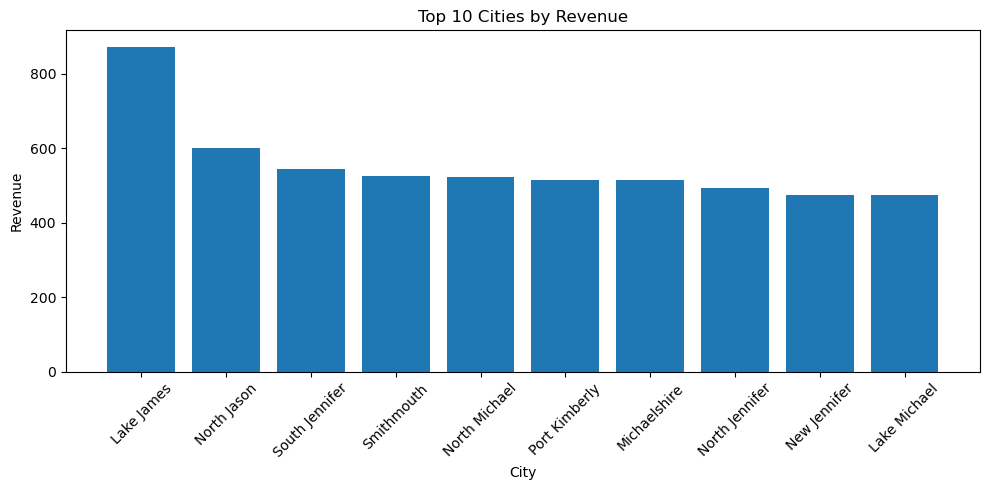

In [52]:
plt.figure(figsize=(10,5))

plt.bar(city_revenue.index, city_revenue.values)

plt.title("Top 10 Cities by Revenue")
plt.xlabel("City")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [53]:
job_revenue = (
    invoice.groupby("job")["final_amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

job_revenue

job
Producer, radio                        1889.08
Engineer, broadcasting (operations)    1806.98
Agricultural consultant                1770.54
Corporate treasurer                    1731.45
Commercial/residential surveyor        1681.48
Heritage manager                       1650.91
Colour technologist                    1609.06
Clothing/textile technologist          1608.80
Research scientist (life sciences)     1594.19
Geochemist                             1585.51
Name: final_amount, dtype: float64

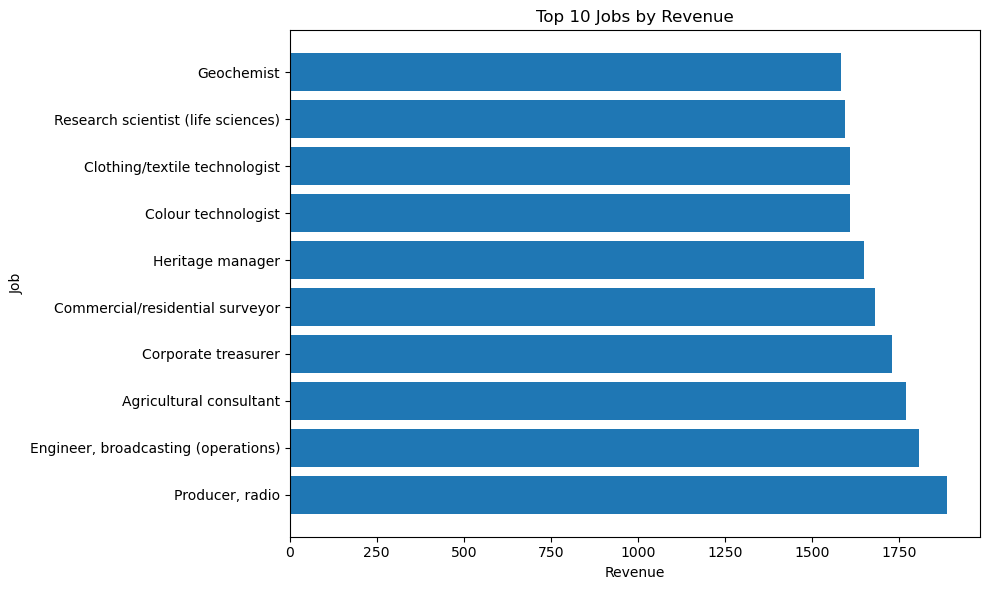

In [54]:
plt.figure(figsize=(10,6))

plt.barh(job_revenue.index, job_revenue.values)

plt.title("Top 10 Jobs by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Job")

plt.tight_layout()

plt.show()

In [55]:
top_products = (
    invoice.groupby("product_id")["qty"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

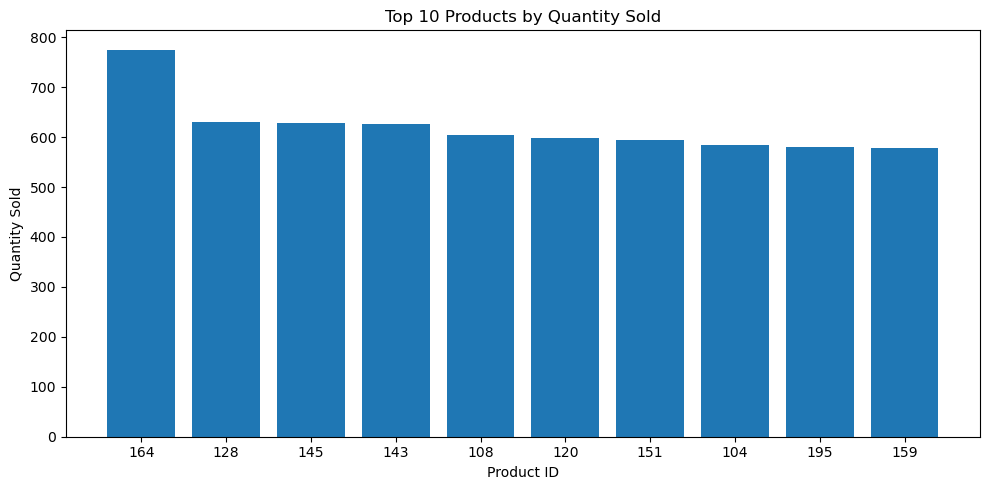

In [56]:
plt.figure(figsize=(10,5))

plt.bar(top_products.index.astype(str), top_products.values)

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Product ID")
plt.ylabel("Quantity Sold")

plt.tight_layout()

plt.show()

In [57]:
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_revenue = (
    invoice.groupby("invoice_month")["final_amount"]
    .sum()
    .reindex(month_order)
)

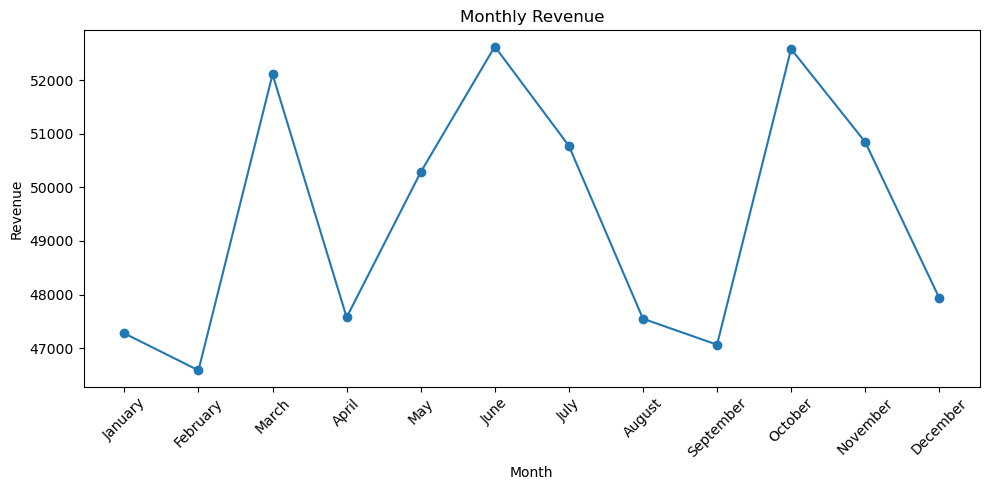

In [58]:
plt.figure(figsize=(10,5))

plt.plot(monthly_revenue.index, monthly_revenue.values, marker="o")

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

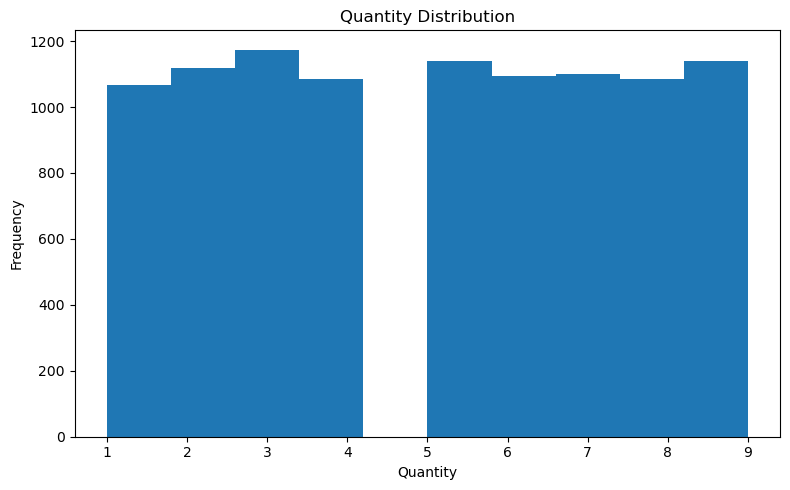

In [59]:
plt.figure(figsize=(8,5))

plt.hist(invoice["qty"], bins=10)

plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

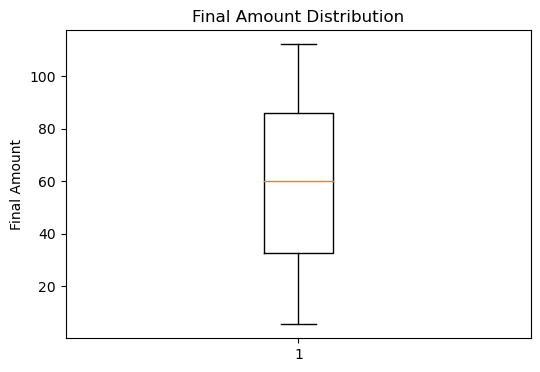

In [60]:
plt.figure(figsize=(6,4))

plt.boxplot(invoice["final_amount"])

plt.title("Final Amount Distribution")
plt.ylabel("Final Amount")

plt.show()

In [61]:
invoice.to_csv(
    "C:/Users/Tanuja/Desktop/Data Analytics Projects/Automated Invoice Generator/Dataset/clean_invoice.csv",
    index=False
)